# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [88]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [89]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [90]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [91]:
numbers = list(range(10))  # список для shuffle

# TODO: двічі ДО set_seed() -- наприклад random.randint(1, 100) і random.shuffle(numbers)
print("двічі ДО set_seed() 1:", random.randint(1, 100))
random.shuffle(numbers)
print("двічі ДО set_seed() 2, shuffle:", numbers)

set_seed()
print("Seed зафіксовано:", SEED)

# TODO: тепер двічі ПІСЛЯ set_seed() -- виклич set_seed() перед КОЖНИМ окремим генеруванням

set_seed()
print("ПІСЛЯ set_seed() 1:", random.randint(1, 100))
set_seed()
print("ПІСЛЯ set_seed() 2:", random.randint(1, 100))

# TODO: тепер ще двічі без проміжних викликів set_seed()

print("без проміжних викликів set_seed() 1:", random.randint(1, 100))
print("без проміжних викликів set_seed() 2:", random.randint(1, 100))

двічі ДО set_seed() 1: 32
двічі ДО set_seed() 2, shuffle: [9, 7, 8, 0, 4, 6, 5, 1, 2, 3]
Seed зафіксовано: 42
ПІСЛЯ set_seed() 1: 82
ПІСЛЯ set_seed() 2: 82
без проміжних викликів set_seed() 1: 15
без проміжних викликів set_seed() 2: 4


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [92]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [93]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [95]:
# TODO: zeros_arr = np.zeros((3, 4))
# TODO: sevens_arr = np.full((3, 4), 7)
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape if zeros_arr is not None else None, zeros_arr.dtype if zeros_arr is not None else None)
print(sevens_arr, sevens_arr.shape if sevens_arr is not None else None, sevens_arr.dtype if sevens_arr is not None else None)


[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [96]:
# TODO: arange_arr = np.arange(0, 20, 2)
# TODO: linspace_arr = np.linspace(0, 1, 5)
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)


[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [97]:
# TODO: identity = np.eye(4)
# TODO: random_ints = np.random.randint(0, 10, size=(3, 3))
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity.ndim)
print(random_ints.ndim)


2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [98]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

# TODO: порахувати mean, std і z_scores = (scores - mean) / std
mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [99]:
arr = np.arange(1, 13)

# TODO: перетворити arr на матрицю 3x4 (reshape), порахувати суми по рядках
# (axis=1) і по стовпцях (axis=0)
matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [100]:
df = pd.DataFrame(
    {
        "Name": [
            "Braund, Mr. Owen Harris",
            "Allen, Mr. William Henry",
            "Bonnell, Miss Elizabeth",
            "Braund, Mr. William Henry",
            "Allen, Mr. Owen Harris",
        ],
        "score": [75, 81, 90, 88, 60],
    }
)

# TODO: відфільтрувати score > 80 і відсортувати за score за спаданням
top = df[df["score"]>80].sort_values(by="score", ascending=False)
print(top)


                        Name  score
2    Bonnell, Miss Elizabeth     90
3  Braund, Mr. William Henry     88
1   Allen, Mr. William Henry     81


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [101]:
# TODO: додати колонку "grade"
# умови: score >= 90 -> "A", score >= 75 -> "B", інакше -> "C"

df["grade"] = np.where(df["score"]>=90, "A", np.where(df["score"]>=75, "B", "C"))
print(df)


                        Name  score grade
0    Braund, Mr. Owen Harris     75     B
1   Allen, Mr. William Henry     81     B
2    Bonnell, Miss Elizabeth     90     A
3  Braund, Mr. William Henry     88     B
4     Allen, Mr. Owen Harris     60     C


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [102]:
# TODO: zeros_t = torch.zeros((2, 3))
# TODO: sevens_t = torch.full((2, 3), 7)
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t, zeros_t.shape, zeros_t.dtype)
print(sevens_t,sevens_t.shape, sevens_t.dtype)


tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3]) torch.float32
tensor([[7, 7, 7],
        [7, 7, 7]]) torch.Size([2, 3]) torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [103]:
# TODO: arange_t = torch.arange(0, 20, 2)
# TODO: linspace_t = torch.linspace(0, 1, 5)
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)


tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [104]:
# TODO: from_list = torch.tensor([[1, 2], [3, 4]])
# TODO: random_t = torch.rand(3, 3)
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list, from_list.shape, from_list.dtype, from_list.ndim )
print(random_t, random_t.shape, random_t.dtype, random_t.ndim )


tensor([[1, 2],
        [3, 4]]) torch.Size([2, 2]) torch.int64 2
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]]) torch.Size([3, 3]) torch.float32 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [105]:
n = 5.0

# TODO: x = torch.tensor(n, requires_grad=True), y = x ** 2, y.backward()
# надрукувати x.grad.item() і порівняти з 2 * n
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()
print("Автоматичний градієнт:", x.grad.item())
print("Аналітичний градієнт:", 2 * n)


Автоматичний градієнт: 10.0
Аналітичний градієнт: 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [106]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

# TODO: цикл градієнтного спуску (20 кроків):
#   loss = (x - 3) ** 2 + 5
#   loss.backward()
#   під torch.no_grad(): x -= lr * x.grad
#   x.grad.zero_()
for _ in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad(): x -= lr * x.grad
    x.grad.zero_()
print(f"x = {x.item():.4f}  (мінімум у x=3)")


x = 2.9654  (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

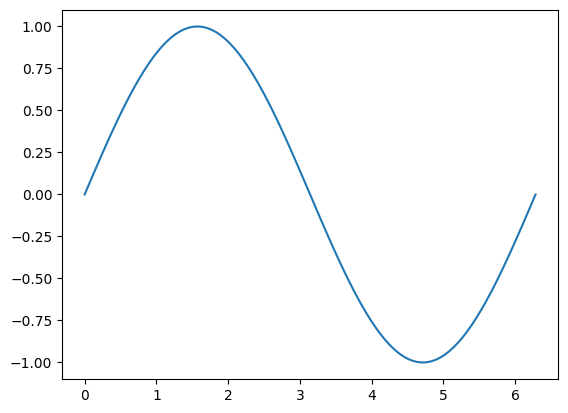

In [107]:
# TODO: xs = np.linspace(0, 2*np.pi, 100), plt.plot(xs, np.sin(xs)), plt.show()
xs = np.linspace(0, 2*np.pi, 100)
plt.plot(xs, np.sin(xs))
plt.show()

**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

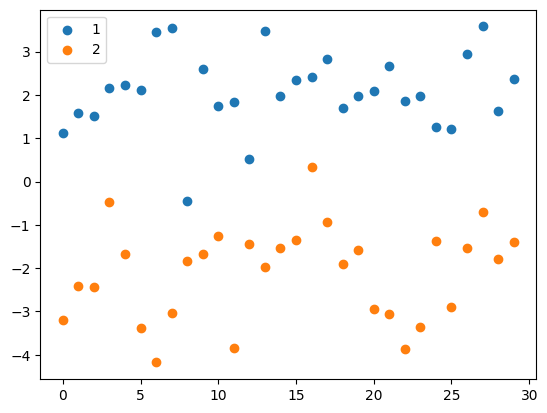

In [108]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

# TODO: scatter обох груп різними кольорами (color="C0"/"C1", label=...),
# додати plt.legend(), plt.show()
plt.scatter(range(30), group_a, color="C0", label="1")
plt.scatter(range(30), group_b, color="C1", label="2")
plt.legend()
plt.show()

---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [109]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

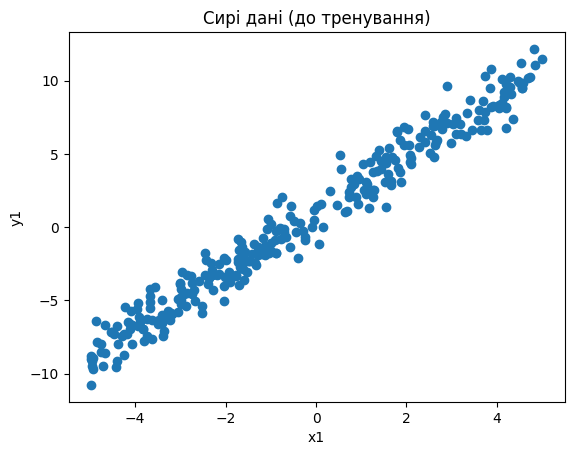

In [110]:
# TODO: Точкова діаграма (scatter plot) з вісями x1 та y1, підпис осей (xlabel/ylabel), заголовок
# "Сирі дані (до тренування)"
plt.scatter(x1.numpy(), y1.numpy())
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [111]:
# TODO: перемішати x1/y1 через torch.randperm(TASK1_N), розбити на
indices = torch.randperm(TASK1_N)
# train/val/test у пропорції 70/15/15
train_size = int(0.70 * TASK1_N)
val_size = int(0.15 * TASK1_N)
# x_train1, y_train1 = ...
# x_val1, y_val1 = ...
# x_test1, y_test1 = ...
train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]
x_train1, y_train1 = x1[train_idx], y1[train_idx]
x_val1, y_val1 = x1[val_idx], y1[val_idx]
x_test1, y_test1 = x1[test_idx], y1[test_idx]
print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [112]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


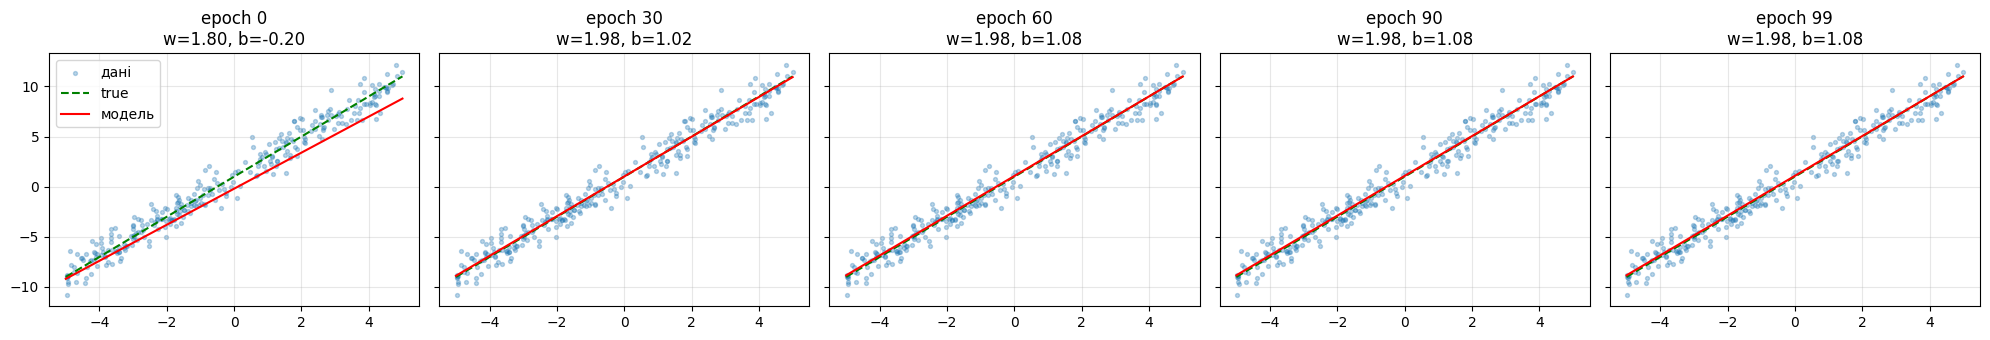

In [113]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

In [114]:
# Сценарій: Прогнозування зростання населення міста залежно від року (кількості років, що минули з 2000-го).
# Уявімо місто, яке активно розвивається. У 2000 році (коли x = 0) його населення становило 500 тисяч осіб (базовий зсув b = 500.0). Щороку завдяки урбанізації та міграції населення зростає в середньому на 15 тисяч осіб (w = 5.0).
N_SAMPLES = 300
TRUE_W = 5.0
TRUE_B = 500.0

x_years = torch.empty(N_SAMPLES, 1).uniform_(0, 30)
noise_pop = 10.0 * torch.randn(N_SAMPLES, 1)
y_pop = TRUE_W * x_years + TRUE_B + noise_pop

df = pd.DataFrame({'years_since_2000': x_years.squeeze().numpy(), 'population_k': y_pop.squeeze().numpy()})
df.to_csv('dataset.csv', index=False)

indices = torch.randperm(N_SAMPLES)
train_size = int(0.70 * N_SAMPLES)
train_idx = indices[:train_size]
x_train_pop = x_years[train_idx]
y_train_pop = y_pop[train_idx]

pop_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(pop_model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()

x_line_pop = torch.linspace(0, 30, 100).unsqueeze(1)
snapshots = []

for epoch in range(15000):
    optimizer.zero_grad()
    y_pred = pop_model(x_train_pop)
    loss = loss_fn(y_pred, y_train_pop)
    loss.backward()
    optimizer.step()

    if epoch % 2500 == 0 or epoch == 14999:
        with torch.no_grad():
            y_line_pred = pop_model(x_line_pop)
        snapshots.append((epoch, pop_model.weight.item(), pop_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:5d}  loss={loss.item():.6f}  "
              f"w={pop_model.weight.item():.4f} (true {TRUE_W})  "
              f"b={pop_model.bias.item():.4f} (true {TRUE_B})")

epoch     0  loss=318223.968750  w=17.6884 (true 5.0)  b=1.6902 (true 500.0)
epoch  2500  loss=4874.948730  w=11.9519 (true 5.0)  b=364.3195 (true 500.0)
epoch  5000  loss=466.536224  w=6.9527 (true 5.0)  b=462.5701 (true 500.0)
epoch  7500  loss=141.764023  w=5.5959 (true 5.0)  b=489.2376 (true 500.0)
epoch 10000  loss=117.837730  w=5.2276 (true 5.0)  b=496.4757 (true 500.0)
epoch 12500  loss=116.074913  w=5.1276 (true 5.0)  b=498.4406 (true 500.0)
epoch 14999  loss=115.945053  w=5.1005 (true 5.0)  b=498.9734 (true 500.0)


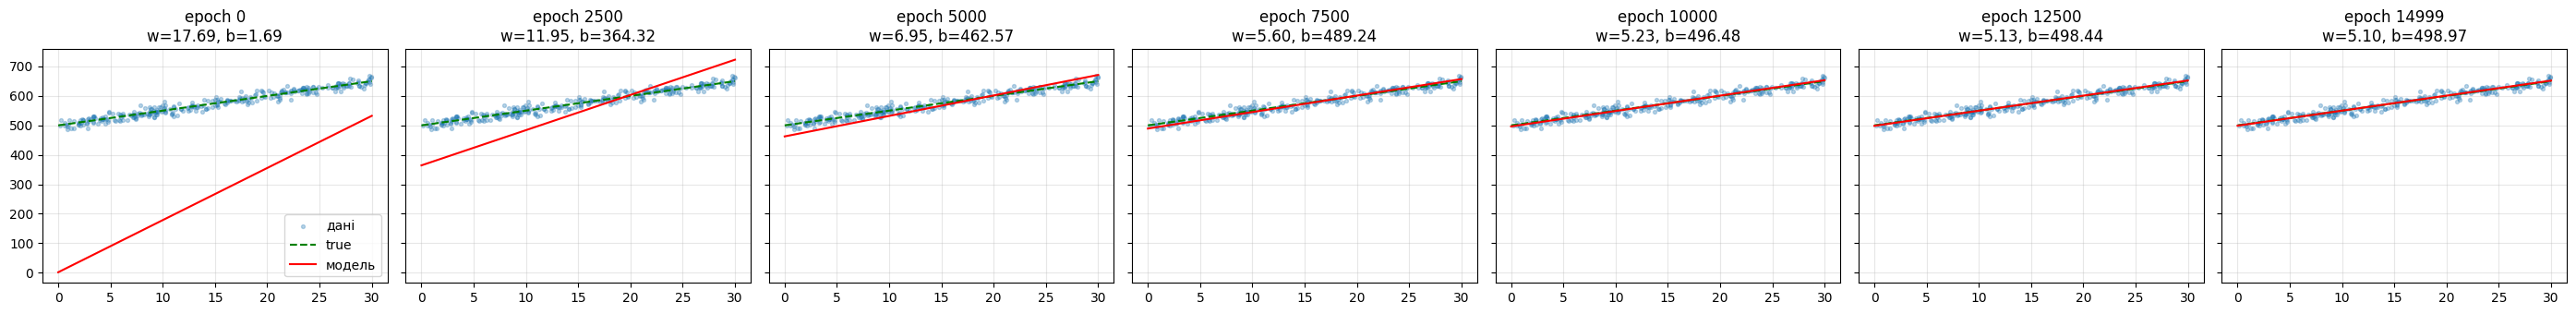

In [115]:
with torch.no_grad():
    y_line_true = TRUE_W * x_line_pop + TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x_years.numpy(), y_pop.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line_pop.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line_pop.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [116]:
MODEL_PATH = os.path.join(ARTIFACT_DIR, "model.pt")
torch.save(pop_model.state_dict(), MODEL_PATH)
print(f"Модель успішно збережена на Google Диск за шляхом:\n{MODEL_PATH}")

Модель успішно збережена на Google Диск за шляхом:
/content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [117]:
!pip install -q gradio

In [118]:
import gradio as gr

In [119]:
model = torch.nn.Linear(1, 1)
model.load_state_dict(torch.load(f"{ARTIFACT_DIR}/model.pt"))
model.eval()

def predict(year):
    x = torch.tensor([[float(year - 2000)]])
    result = model(x).item()
    return max(0.0, round(result, 2))

gr.Interface(fn=predict, inputs="number", outputs="number").launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://42c3605bb39598b451.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```